# Notebook 4: Regime Detection

 Starting Regime Detection...


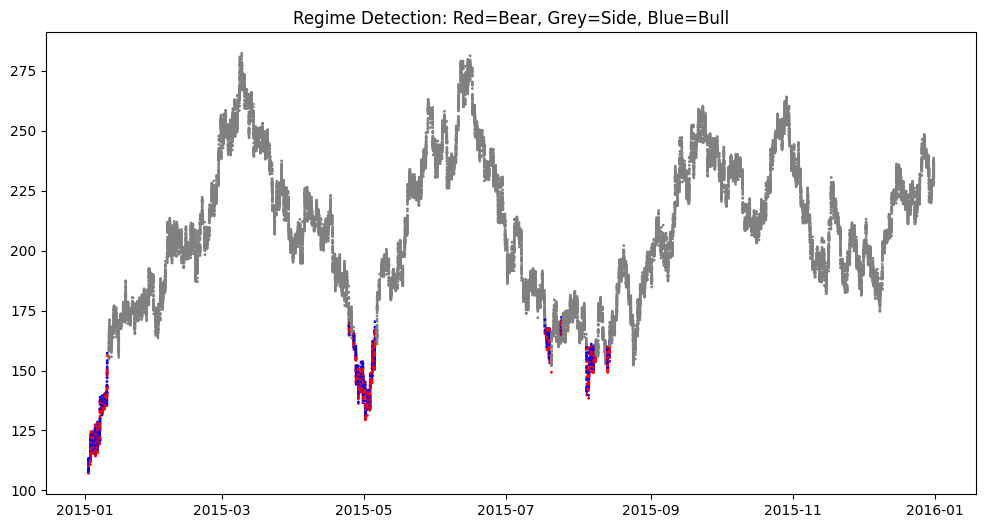

 Regimes Detected & Saved.


In [3]:
import pandas as pd
import numpy as np
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import seaborn as sns

print(" Starting Regime Detection...")
df = pd.read_csv("../data/nifty_features_5min.csv", index_col='timestamp', parse_dates=True)

# 1. HMM Training (Task 3.1)
# Using Returns and IV to find regimes
X = df[['returns', 'average_iv']].values
model = GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
model.fit(X)
regimes = model.predict(X)

# 2. Map Regimes to Logic (Bull/Bear/Side)
# Logic: We sort by Mean Return. Highest = Bull (+1), Lowest = Bear (-1), Mid = Side (0)
means = model.means_[:, 0] # Returns column
sorted_idx = np.argsort(means)
map_dict = {sorted_idx[0]: -1, sorted_idx[1]: 0, sorted_idx[2]: 1}
df['regime'] = [map_dict[r] for r in regimes]

# 3. Visualization (Task 3.2)
plt.figure(figsize=(12, 6))
colors = {-1: 'red', 0: 'grey', 1: 'blue'}
plt.scatter(df.index, df['close'], c=df['regime'].map(colors), s=1, label='Regime')
plt.title("Regime Detection: Red=Bear, Grey=Side, Blue=Bull")
plt.savefig("../results/output-1.png") # Save for PPT
plt.show()

# 4. Save
df.to_csv("../data/nifty_regimes.csv")
print(" Regimes Detected & Saved.")